In [6]:
import sys
import subprocess

# Menginstall ulang pip di dalam environment yang aktif
subprocess.check_call([sys.executable, "-m", "ensurepip", "--default-pip"])

# Baru kemudian install library yang dibutuhkan
subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn", "scikit-learn", "pandas", "matplotlib", "plotly"])

0

# Linear and Multiple Regression from Scratch
This notebook demonstrates how to implement Simple Linear Regression and Multiple Linear Regression using two fundamental approaches:
1. **Ordinary Least Squares (OLS):** The closed-form mathematical solution using the Normal Equation.
2. **Gradient Descent:** An iterative optimization algorithm.

**Required Libraries:** `numpy` for matrix operations and `matplotlib` for visualization.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import time
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# Set a random seed for reproducibility
np.random.seed(42)

In [8]:
# HELPER FUNCTIONS

# --- SEL 1: HELPER FUNCTIONS (VISUALIZATION) ---

def predict_plot_linear_regression(intercept, slope, X, y, m):
    y_pred = intercept + slope * X
    plt.scatter(X, y, color="blue", alpha=0.6, label="Data Points")
    plt.plot(X, y_pred, color="red", linewidth=2, label=f"Regression Line: $y = {intercept:.2f} + {slope:.2f}X$")
    for i in range(m):
        plt.plot([X[i][0], X[i][0]], [y[i][0], y_pred[i][0]], color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
    plt.title("Linear Regression with Residuals (Error Lines)")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True, linestyle=":", alpha=0.6)

def plot_gradient_visual():
    # ... (Kode Interactive 3D Gradient Descent sesuai lampiran Anda) ...
    pass

def plot_regression_residual(x, y):
    # ... (Kode Residual Plot sesuai lampiran Anda) ...
    pass

# --- SEL 2: MULTIPLE REGRESSION LOGIC ---

def create_data(n_samples=1000, n_features=3):
    X = np.random.randn(n_samples, n_features)
    true_weights = np.random.uniform(1, 10, n_features)
    y = X.dot(true_weights) + np.random.normal(0, 0.5, n_samples) + 5
    return X, y

def run_ols(X, y):
    model = LinearRegression()
    start_time = time.time()
    model.fit(X, y)
    end_time = time.time()
    mse = mean_squared_error(y, model.predict(X))
    return mse, end_time - start_time

def run_gradient_descent(X, y, lr=0.01, iters=1000):
    m, n = X.shape
    X_b = np.c_[np.ones((m, 1)), X] 
    w = np.random.randn(n + 1)
    start_time = time.time()
    for _ in range(iters):
        gradients = 2/m * X_b.T.dot(X_b.dot(w) - y)
        w = w - lr * gradients
    end_time = time.time()
    mse = mean_squared_error(y, X_b.dot(w))
    return mse, end_time - start_time

    
    
def predict_plot_linear_regression(intercept, slope, X, y, m):
    # Fit linear regression line: y = mx + c

    y_pred = intercept + slope * X

    # Create the visualization
    plt.scatter(X, y, color="blue", alpha=0.6, label="Data Points")
    plt.plot(
        X,
        y_pred,
        color="red",
        linewidth=2,
        label=f"Regression Line: $y = {intercept:.2f} + {slope:.2f}X$",
    )

    # Draw error lines (residuals) from each point to the regression line
    for i in range(m):
        plt.plot(
            [X[i][0], X[i][0]],
            [y[i][0], y_pred[i][0]],
            color="gray",
            linestyle="--",
            linewidth=0.8,
            alpha=0.5,
        )

    plt.title("Linear Regression with Residuals (Error Lines)")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True, linestyle=":", alpha=0.6)


def plot_gradient_visual():
    X = 2 * np.random.rand(100, 1)
    y = 4 + 2 * X + np.random.randn(100, 1) * 0.5

    # 2. Gradient Descent Implementation
    m, b = -10.0, -10.0  # Random starting points far from the minimum
    learning_rate = 0.01
    iterations = 1000
    n = len(X)

    # Lists to store the "path"
    m_history, b_history, mse_history = [m], [b], [np.mean((y - (m * X + b)) ** 2)]

    for _ in range(iterations):
        y_pred = m * X + b
        dm = (-2 / n) * np.sum(X * (y - y_pred))
        db = (-2 / n) * np.sum(y - y_pred)

        m -= learning_rate * dm
        b -= learning_rate * db

        m_history.append(m)
        b_history.append(b)
        mse_history.append(np.mean((y - (m * X + b)) ** 2))

    # 3. Create MSE Surface Data
    m_range = np.linspace(-2, 6, 50)
    b_range = np.linspace(0, 10, 50)
    M, B = np.meshgrid(m_range, b_range)

    # Vectorized MSE calculation for the surface
    Z = np.array(
        [
            np.mean((y - (m_val * X + b_val)) ** 2)
            for m_val, b_val in zip(np.ravel(M), np.ravel(B))
        ]
    )
    Z = Z.reshape(M.shape)

    # 4. Build the Plotly Figure
    fig = go.Figure()

    # Add the Cost Surface
    fig.add_trace(
        go.Surface(
            x=m_range,
            y=b_range,
            z=Z,
            colorscale="Rainbow_r",
            opacity=0.8,
            colorbar_title="MSE Cost",
            showlegend=False,
            showscale=False,
        )
    )
    fig.add_trace(
        go.Surface(
            x=m_range,
            y=b_range,
            z=Z,
            colorscale="Rainbow_r",
            opacity=0.8,
            colorbar_title="MSE Cost",
            showlegend=False,
            showscale=False,
            # --- ADD THESE LINES ---
            hovertemplate=(
                "Slope (m): %{x:.3f}<br>"
                "Intercept (b): %{y:.3f}<br>"
                "MSE Loss: %{z:.3f}"
                "<extra></extra>"
            ),
        )
    )
    fig.update_layout(
        title="Interactive 3D Gradient Descent: Path to Minimum MSE",
        scene=dict(
            xaxis_title="Slope (m)",
            yaxis_title="Intercept (b)",
            zaxis_title="MSE Loss",
            camera=dict(eye=dict(x=1.8, y=1.8, z=1.2)),
        ),
        width=900,
        height=700,
    )

    fig.show()


def plot_regression_residual(x, y):
    df = pd.DataFrame({"X": x, "Y": y})

    # 2. Setup the figure for two plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # --- LEFT PLOT: Original Data ---
    sns.scatterplot(data=df, x="X", y="Y", ax=ax1, alpha=0.6)
    sns.regplot(
        data=df, x="X", y="Y", scatter=False, color="red", ax=ax1
    )  # Linear fit line
    ax1.set_title("1. Original Data with Linear Fit")
    ax1.set_xlabel("Independent Variable (X)")
    ax1.set_ylabel("Dependent Variable (Y)")

    # --- RIGHT PLOT: Residual Plot ---
    sns.residplot(
        data=df,
        x="X",
        y="Y",
        lowess=True,
        ax=ax2,
        line_kws={"color": "red", "lw": 2},
        scatter_kws={"alpha": 0.6},
    )
    ax2.set_title("2. Residual Plot (The Leftovers)")
    ax2.set_xlabel("Independent Variable (X)")
    ax2.set_ylabel("Error (Residual)")

    plt.tight_layout()
    plt.show()

    # --- MASUKKAN KODE INI DI SEL BARU SETELAH HELPER FUNCTIONS ---

# 1. Fungsi generator data dengan jumlah fitur dinamis
def create_data(n_samples=1000, n_features=3):
    X = np.random.randn(n_samples, n_features)
    # Membuat bobot asli secara acak
    true_weights = np.random.uniform(1, 10, n_features)
    # Rumus: Y = X.W + b + noise
    y = X.dot(true_weights) + np.random.normal(0, 0.5, n_samples) + 5
    return X, y

# 2. Fungsi hitung OLS (Analitis)
def run_ols(X, y):
    model = LinearRegression()
    start_time = time.time()
    model.fit(X, y)
    end_time = time.time()
    mse = mean_squared_error(y, model.predict(X))
    return mse, end_time - start_time

# 3. Fungsi hitung Gradient Descent (Iteratif/Vektor)
def run_gradient_descent(X, y, lr=0.01, iters=1000):
    m, n = X.shape
    # Tambahkan kolom intercept (angka 1)
    X_b = np.c_[np.ones((m, 1)), X]
    w = np.random.randn(n + 1)
    
    start_time = time.time()
    for _ in range(iters):
        # Hitung Gradient secara vektor
        gradients = 2/m * X_b.T.dot(X_b.dot(w) - y)
        # Update Bobot
        w = w - lr * gradients
    end_time = time.time()
    
    y_pred = X_b.dot(w)
    mse = mean_squared_error(y, y_pred)
    return mse, end_time - start_time

    # --- MASUKKAN KODE INI DI SEL PALING BAWAH UNTUK MELIHAT HASILNYA ---

# Daftar pengujian fitur: 3, 5, dan 10 fitur
fitur_list = [3, 5, 10]
data_hasil = []
scaler = StandardScaler()

print("Sedang memproses perbandingan 3, 5, dan 10 Fitur...\n")

for n in fitur_list:
    # Generate data sesuai jumlah fitur
    X_raw, y = create_data(n_samples=1000, n_features=n)
    
    # Preprocessing: Scaling (Wajib agar Gradient Descent tidak 'pecah')
    X = scaler.fit_transform(X_raw)
    
    # Hitung dengan OLS
    mse_ols, t_ols = run_ols(X, y)
    
    # Hitung dengan Gradient Descent
    mse_gd, t_gd = run_gradient_descent(X, y)
    
    # Simpan hasil ke tabel
    data_hasil.append({
        'Jumlah Fitur': n,
        'MSE (OLS)': round(mse_ols, 6),
        'MSE (GD)': round(mse_gd, 6),
        'Selisih MSE': round(abs(mse_ols - mse_gd), 6),
        'Waktu OLS (s)': f"{t_ols:.6f}",
        'Waktu GD (s)': f"{t_gd:.6f}"
    })

# Tampilkan dalam bentuk tabel Pandas
df_hasil = pd.DataFrame(data_hasil)
print("TABEL PERBANDINGAN PERFORMA")
display(df_hasil)

Sedang memproses perbandingan 3, 5, dan 10 Fitur...

TABEL PERBANDINGAN PERFORMA


,Jumlah Fitur,MSE (OLS),MSE (GD),Selisih MSE,Waktu OLS (s),Waktu GD (s)
0,3,0.244465,0.244465,0.0,0.007877,0.015899
1,5,0.230163,0.230163,0.0,0.000000,0.031956
2,10,0.249078,0.249078,0.0,0.000000,0.029561


## Simple Linear Regression (One Feature)

First, let's generate some synthetic data for a simple linear regression problem ($y = 3X + 4 + \text{noise}$).

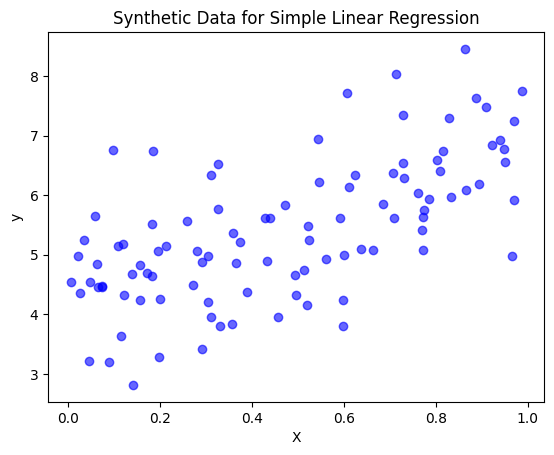

In [3]:
# Generate 100 data points
m = 100
X = np.random.rand(m, 1)
y = 4 + 3 * X + np.random.randn(m, 1)


plt.scatter(X, y, color="blue", alpha=0.6)
plt.title("Synthetic Data for Simple Linear Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

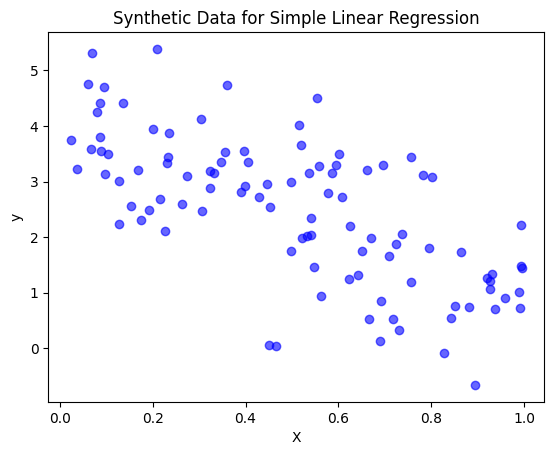

In [20]:
# Generate 100 data points
m = 100
X_descent = np.random.rand(m, 1)
y_descent = 4 - 3 * X_descent + np.random.randn(m, 1)


plt.scatter(X_descent, y_descent, color="blue", alpha=0.6)
plt.title("Synthetic Data for Simple Linear Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

## Errror/Loss Function

$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

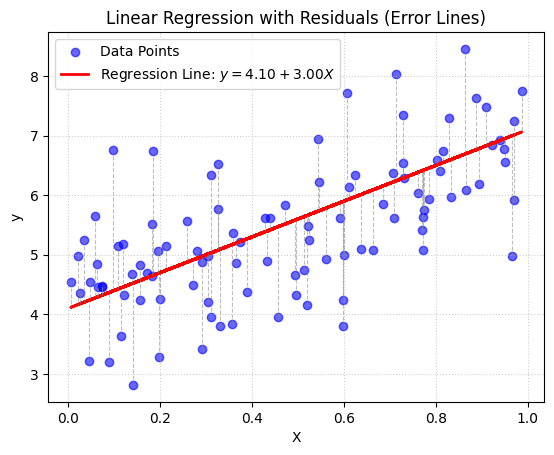

In [4]:
predict_plot_linear_regression(intercept=4.1, slope=3, X=X, y=y, m=m)

## Linearity Assumption 

Using residual plot between features ($X$) and MSE, we can derive how linear the data are.

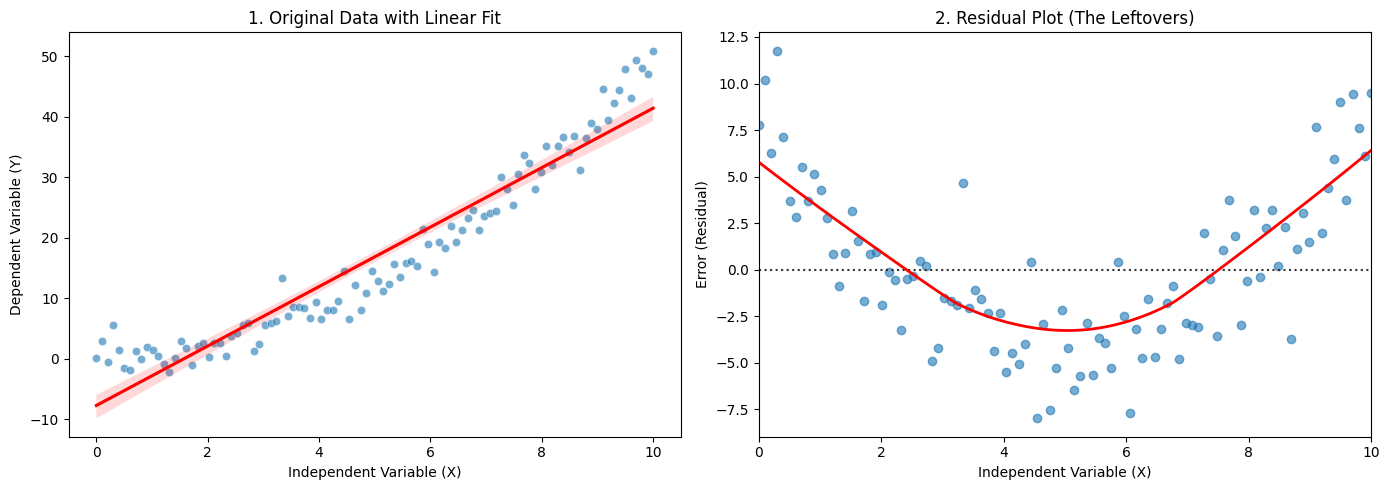

In [5]:
sample_x = np.linspace(0, 10, 100)
# This is quadratic (x^2), making it non-linear
sample_y = 0.5 * sample_x**2 + np.random.normal(0, 2, 100)
plot_regression_residual(sample_x, sample_y)

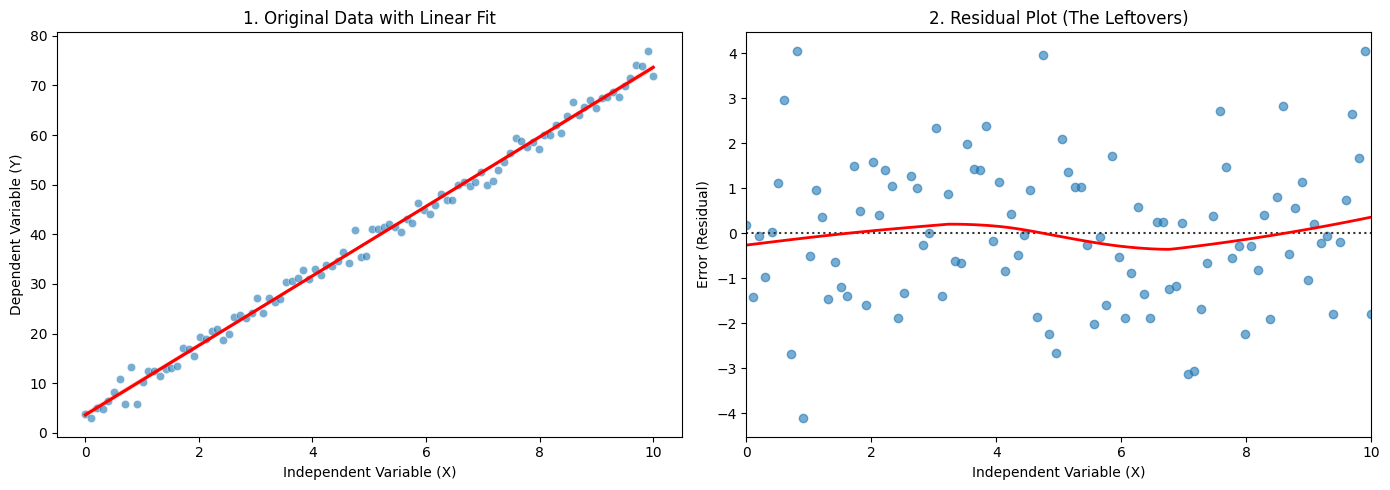

In [6]:
sample_x = np.linspace(0, 10, 100)
sample_y = 3.4 + 7 * sample_x + np.random.normal(0, 2, 100)
plot_regression_residual(sample_x, sample_y)

### Ordinary Least Squares (OLS) Solution
The Normal Equation finds the parameters $\theta$ that minimize the cost function directly:
$$\hat{\theta} = (X^T X)^{-1} X^T y$$

To account for the intercept, we must add a column of $1$ to our feature matrix $X$.

---
$$X$$
---

In [7]:
X[:5]

array([[0.37454012],
       [0.95071431],
       [0.73199394],
       [0.59865848],
       [0.15601864]])

In [8]:
X_offset = np.c_[np.ones(X.shape[0]), X]
X_offset[:5]

array([[1.        , 0.37454012],
       [1.        , 0.95071431],
       [1.        , 0.73199394],
       [1.        , 0.59865848],
       [1.        , 0.15601864]])

---
$$(X^T X)$$
---


![DOT product](imgs/4_1.png)


In [9]:
# 2. Calculate the Normal Equation: (X^T * X)^-1 * X^T * y
# Step A: X transpose times X
xtx = np.dot(X_offset.T, X_offset)
xtx

array([[100.        ,  47.01807434],
       [ 47.01807434,  30.86848816]])

---
$$(X^T X)^{-1}$$
---

In [10]:
# Step B: Inverse of (X^T * X)
xtx_inv = np.linalg.inv(xtx)
xtx_inv

array([[ 0.03523199, -0.05366444],
       [-0.05366444,  0.11413577]])

---
$$X^T y$$
---

In [11]:
# Step C: X transpose times y
xty = np.dot(X_offset.T, y)
xty

array([[540.946187  ],
       [276.59866454]])

$$\hat{\theta} = (X^T X)^{-1} X^T y$$

In [12]:
# Step D: Final coefficients
beta = np.dot(xtx_inv, xty)
intercept = beta[0]
coefficients = beta[1:]
beta

array([[4.21509616],
       [2.54022677]])

In [13]:
from sklearn.linear_model import LinearRegression

ols_reg = LinearRegression()
ols_reg.fit(X, y)

print(ols_reg.intercept_, ols_reg.coef_)

[4.21509616] [[2.54022677]]


### Gradient Descent Solution


$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$
$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - X\theta)^2$$



### **1. The Objective**
Find the optimal slope ($m$) and y-intercept ($b$) for the linear equation $y = mx + b$ to best fit your data points.

### **2. The Cost Function: Mean Squared Error (MSE)**
Measure the average squared difference between your actual data ($y_i$) and your line's predictions ($mx_i + b$).
$$J(m, b) = \frac{1}{N} \sum_{i=1}^{N} (y_i - (mx_i + b))^2$$

### **3. The Gradients**
Compute the partial derivatives of the Cost Function. These calculate the slope of the error, telling you how much the error changes if you tweak $m$ or $b$:
* **Gradient of :** 
 $$m:\frac{\partial J}{\partial m} = -\frac{2}{N} \sum_{i=1}^{N} x_i (y_i - (mx_i + b))$$
* **Gradient of :**
$$b: \frac{\partial J}{\partial b} = -\frac{2}{N} \sum_{i=1}^{N} (y_i - (mx_i + b))$$

### **4. The Update Rule**
Adjust your current $m$ and $b$ by moving in the *opposite* direction of the gradients (to reduce the error), scaled by your step size, the learning rate ($\alpha$):
$$m := m - \alpha \frac{\partial J}{\partial m}$$
$$b := b - \alpha \frac{\partial J}{\partial b}$$

### **5. The Loop**
Repeat steps 2 through 4 over and over. You stop when the updates become so small that the error ($J$) is no longer decreasing, meaning you have found the line of best fit.

In [14]:
plot_gradient_visual()

[4.20545486] [2.4634211]


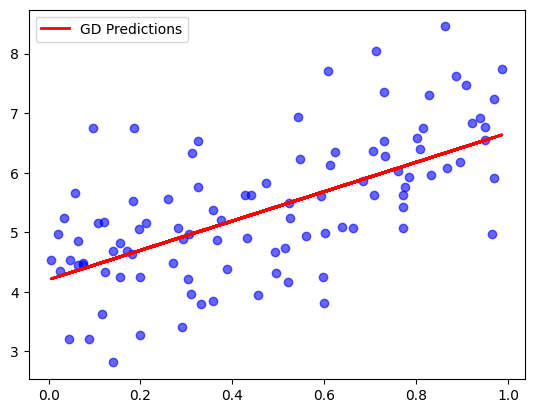

In [15]:
from sklearn.linear_model import SGDRegressor


eta = 0.1
n_iterations = 1000
gd_reg = SGDRegressor(loss="squared_error", max_iter=n_iterations, eta0=0.1)
gd_reg.fit(X, y.ravel())

print(gd_reg.intercept_, gd_reg.coef_)
y_predict_gd = gd_reg.predict(X)

plt.plot(X, y_predict_gd.ravel(), "r-", linewidth=2, label="GD Predictions")
plt.scatter(X, y, color="blue", alpha=0.6)
plt.legend()
plt.show()

## Multiple Linear Regression (Multiple Features)

Now, let's expand this to multiple features. We will generate data with 3 features:
$$y = 5 + 2X_1 - 3X_2 + 1.5X_3 + \text{noise}$$

In [16]:
# Generate synthetic data with 3 features
m_multi = 200
X_multi = np.random.rand(m_multi, 3)

# True parameters: Intercept = 5, weights = [2, -3, 1.5]
true_weights = np.array([[2], [-3], [1.5]])
y_multi = 5 + X_multi.dot(true_weights) + np.random.randn(m_multi, 1)

### Multiple Regression using OLS
The mathematical beauty of vectorized operations is that the exact same Normal Equation formula applies regardless of the number of features.

OLS from scratch

In [17]:
# Add bias term (column of 1s)
X_multi_b = np.c_[np.ones((m_multi, 1)), X_multi]
# Compute OLS using the Normal Equation
theta_multi_ols = (
    np.linalg.inv(X_multi_b.T.dot(X_multi_b)).dot(X_multi_b.T).dot(y_multi)
)
print(theta_multi_ols[0][0], theta_multi_ols[1:].flatten())

4.80912672609027 [ 1.75932551 -2.64102319  1.8314071 ]


OLS using Scikit-Learn

In [18]:
ols_mul_reg = LinearRegression()
ols_mul_reg.fit(X_multi, y_multi)
print(ols_mul_reg.intercept_, ols_mul_reg.coef_)

[4.80912673] [[ 1.75932551 -2.64102319  1.8314071 ]]


### Multiple Regression using Gradient Descent
Similarly, the vectorized form of Gradient Descent handles multiple features seamlessly.

In [19]:
eta_multi = 0.1
n_iterations_multi = 1000

gd_mul_reg = SGDRegressor(loss="squared_error", max_iter=n_iterations, eta0=0.1)
gd_mul_reg.fit(X_multi, y_multi.ravel())
print(gd_mul_reg.intercept_, gd_mul_reg.coef_)

[4.6223713] [ 1.82423949 -2.47624386  1.93566867]
